In [1]:
import sys, os
import pandas as pd

sys.path.append(os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

In [2]:
from src.data_cleaning import load_raw_data, clean_data
from src.feature_engineering import engineer_features

df_raw = load_raw_data()
df = clean_data(df_raw)
print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (133, 13)


,الحي,الشارع,الطابق,عدد الغرف,عدد الحمامات,المساحة (م2),الاتجاه,الوجهة,الإكساء,عدد الشقق في كل طابق,موقف سيارة,وجود مصعد,السعر
0,المريديان,الأنوار,4,4,1,100,غربي,أمامي,وسط,3,لا,لا,83000
1,المريديان,الأنوار,2,4,1,120,شرقي,خلفي,ممتاز,2,لا,نعم,100000
2,المريديان,الأنوار,3,4,1,100,غربي,أمامي,جيد,3,لا,لا,90000
3,المريديان,الأنوار,2,4,1,100,غربي,أمامي,ضعيف,3,لا,لا,88000
4,المريديان,الأنوار,1,4,1,100,غربي,أمامي,ممتاز,3,لا,لا,95000


In [3]:
df = engineer_features(df)
df.dtypes

الحي                    object
الشارع                  object
الطابق                   int64
عدد الغرف                int64
عدد الحمامات             int64
المساحة (م2)             int64
الوجهة                   int64
الإكساء                  int64
عدد الشقق في كل طابق     int64
موقف سيارة               int64
وجود مصعد                int64
السعر                    int64
اتجاه_شرقي                bool
اتجاه_شمالي               bool
اتجاه_غربي                bool
dtype: object

## Numeric sanity check

In [4]:
numeric_cols = ['عدد الغرف', 'عدد الحمامات', 'المساحة (م2)', 'عدد الشقق في كل طابق', 'السعر']
df[numeric_cols].describe()

,عدد الغرف,عدد الحمامات,المساحة (م2),عدد الشقق في كل طابق,السعر
count,133.000000,133.000000,133.000000,133.000000,133.000000
mean,4.135338,1.315789,108.406015,2.646617,99285.714286
std,1.020858,0.595035,37.124491,0.605474,34870.012173
min,3.000000,1.000000,65.000000,2.000000,42000.000000
25%,3.000000,1.000000,80.000000,2.000000,79000.000000
50%,4.000000,1.000000,100.000000,3.000000,90000.000000
75%,5.000000,1.000000,120.000000,3.000000,110000.000000
max,7.000000,3.000000,250.000000,4.000000,225000.000000


## Train/test split

In [5]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c not in ['السعر', 'الحي', 'الشارع']]
X = df[feature_cols + ['الشارع', 'الحي']]
y = df['السعر']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 113 | Test: 20


## Correlation with price (training data only)

In [6]:
train_with_price = X_train.copy()
train_with_price['السعر'] = y_train
train_with_price.corr(numeric_only=True)['السعر'].sort_values(ascending=False)

السعر                   1.000000
المساحة (م2)            0.852382
عدد الحمامات            0.850510
عدد الغرف               0.839575
الوجهة                  0.659135
موقف سيارة              0.494724
اتجاه_غربي              0.333721
الإكساء                 0.286521
اتجاه_شمالي             0.115161
وجود مصعد               0.060185
الطابق                  0.049288
اتجاه_شرقي             -0.144977
عدد الشقق في كل طابق   -0.447719
Name: السعر, dtype: float64

In [7]:
train_with_price.groupby('الطابق')['السعر'].mean().sort_index()

الطابق
-1     72333.333333
 0    101571.428571
 1     98272.727273
 2    106923.076923
 3    109800.000000
 4     82615.384615
Name: السعر, dtype: float64

In [8]:
from sklearn.feature_selection import mutual_info_regression

numeric_features = [c for c in X_train.columns if c not in ['الشارع', 'الحي']]
mi_scores = mutual_info_regression(X_train[numeric_features], y_train, random_state=42)

mi_series = pd.Series(mi_scores, index=numeric_features).sort_values(ascending=False)
print(mi_series)

المساحة (م2)            0.685300
عدد الغرف               0.602069
عدد الحمامات            0.484431
الوجهة                  0.293047
عدد الشقق في كل طابق    0.170149
موقف سيارة              0.165634
اتجاه_شمالي             0.091433
اتجاه_شرقي              0.062132
الإكساء                 0.046137
اتجاه_غربي              0.039881
وجود مصعد               0.037477
الطابق                  0.015638
dtype: float64


In [9]:
discrete_cols = ['الطابق', 'الإكساء', 'الوجهة', 'موقف سيارة', 'وجود مصعد',
                  'اتجاه_شمالي', 'اتجاه_شرقي', 'اتجاه_جنوبي', 'اتجاه_غربي']
discrete_mask = [c in discrete_cols for c in numeric_features]

mi_scores = mutual_info_regression(X_train[numeric_features], y_train,
                                    discrete_features=discrete_mask, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_features).sort_values(ascending=False)
print(mi_series)

المساحة (م2)            0.669475
عدد الغرف               0.593070
عدد الحمامات            0.436098
الوجهة                  0.298215
موقف سيارة              0.156807
عدد الشقق في كل طابق    0.137076
وجود مصعد               0.077230
اتجاه_شمالي             0.074438
الإكساء                 0.053085
اتجاه_غربي              0.049016
اتجاه_شرقي              0.031507
الطابق                  0.030339
dtype: float64


In [10]:
from src.feature_engineering import target_encode_column

# Drop neighborhood (constant, no signal yet)
X_train = X_train.drop(columns=['الحي'])
X_test = X_test.drop(columns=['الحي'])

X_train, X_test, street_map = target_encode_column(X_train, X_test, y_train, column='الشارع', smoothing=10)

print(street_map)
X_train.head()

الشارع
الأنوار     94772.056852
الدرويش    103689.422672
الفندق     106203.913748
النورس     102498.298162
وردشان      86499.115044
dtype: float64


,الطابق,عدد الغرف,عدد الحمامات,المساحة (م2),الوجهة,الإكساء,عدد الشقق في كل طابق,موقف سيارة,وجود مصعد,اتجاه_شرقي,اتجاه_شمالي,اتجاه_غربي,الشارع_encoded
36,3,5,2,140,1,2,2,0,0,False,True,False,103689.422672
16,2,4,1,120,0,1,2,0,1,False,True,False,94772.056852
18,4,4,1,120,0,1,2,0,1,False,False,True,94772.056852
10,0,6,2,180,1,0,2,0,0,False,False,False,94772.056852
65,4,4,1,100,0,2,3,0,0,False,False,True,106203.913748


In [11]:
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [13]:
from src.train import tune_tree_models

best_estimators, tuned_results_df = tune_tree_models(X_train, y_train, cv_folds=5)
tuned_results_df

,Model,Best Params,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,XGBoost,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",9025.704199,2707.968954,5766.976270,970.536980,0.915905,0.067150
1,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'min_sa...",9853.688842,2858.510085,6409.403145,1127.746875,0.899750,0.070151
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",12406.290353,3154.661048,8154.824057,1494.815407,0.847599,0.092294


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from src.train import evaluate_on_test, log_results
from sklearn.linear_model import Ridge

# Final XGBoost - use the tuned version from grid search
final_xgb = best_estimators['XGBoost']
final_xgb.fit(X_train, y_train)

# Final Ridge - retrain fresh on full training set
final_ridge = Ridge(alpha=1.0, random_state=42)
final_ridge.fit(X_train, y_train)

# Evaluate both individually on the TEST set
xgb_metrics, xgb_preds = evaluate_on_test(final_xgb, X_test, y_test)
ridge_metrics, ridge_preds = evaluate_on_test(final_ridge, X_test, y_test)

# Average their predictions
avg_preds = (xgb_preds + ridge_preds) / 2
avg_rmse = mean_squared_error(y_test, avg_preds) ** 0.5
avg_mae = mean_absolute_error(y_test, avg_preds)
avg_r2 = r2_score(y_test, avg_preds)
avg_metrics = {'RMSE': avg_rmse, 'MAE': avg_mae, 'R2': avg_r2}

# Log all three
log_results({'Model': 'XGBoost (tuned)', 'Stage': 'test_set_final', **xgb_metrics})
log_results({'Model': 'Ridge Regression', 'Stage': 'test_set_final', **ridge_metrics})
log_results({'Model': 'Average (XGBoost + Ridge)', 'Stage': 'test_set_final', **avg_metrics})

print("\nXGBoost:", xgb_metrics)
print("Ridge:", ridge_metrics)
print("Average:", avg_metrics)

Logged: XGBoost (tuned) | RMSE=6380.72 | MAE=4932.82 | R2=0.9707
Logged: Ridge Regression | RMSE=10811.59 | MAE=9366.24 | R2=0.9159
Logged: Average (XGBoost + Ridge) | RMSE=7514.94 | MAE=6403.68 | R2=0.9594

XGBoost: {'RMSE': 6380.72409684042, 'MAE': 4932.81884765625, 'R2': 0.9707186222076416}
Ridge: {'RMSE': 10811.593160103026, 'MAE': 9366.239341053511, 'R2': 0.9159319370052832}
Average: {'RMSE': 7514.942653181977, 'MAE': 6403.678919799596, 'R2': 0.9593834535920688}


Matplotlib is building the font cache; this may take a moment.


عدد الحمامات            0.308152
المساحة (م2)            0.296897
الوجهة                  0.136521
عدد الشقق في كل طابق    0.086952
عدد الغرف               0.062086
الشارع_encoded          0.039980
الإكساء                 0.021699
اتجاه_غربي              0.018692
الطابق                  0.012975
اتجاه_شمالي             0.012436
وجود مصعد               0.001908
اتجاه_شرقي              0.001701
موقف سيارة              0.000000
dtype: float32


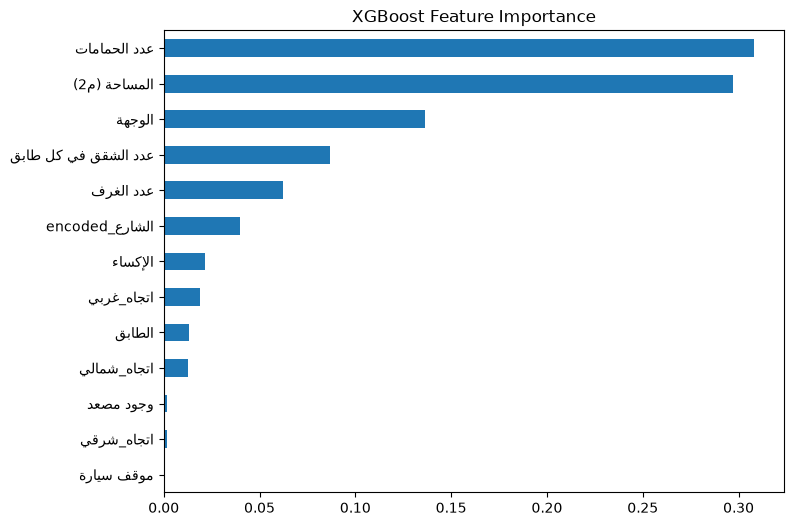

In [17]:
import matplotlib.pyplot as plt

importances = pd.Series(final_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [18]:
importance_df = importances.reset_index()
importance_df.columns = ['Feature', 'Importance']
importance_df['Model'] = 'XGBoost (tuned)'
importance_df['timestamp'] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

import os
log_path = "../results/feature_importance_log.csv"
if os.path.exists(log_path):
    importance_df.to_csv(log_path, mode='a', header=False, index=False)
else:
    importance_df.to_csv(log_path, mode='a', header=True, index=False)

print("Feature importance logged.")

Feature importance logged.


In [19]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate, KFold

drop_cols = ['موقف سيارة', 'وجود مصعد', 'اتجاه_شرقي']
X_train_reduced = X_train.drop(columns=drop_cols)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'RMSE': 'neg_root_mean_squared_error', 'MAE': 'neg_mean_absolute_error', 'R2': 'r2'}

# Use a fresh, unfitted clone of the tuned XGBoost (same hyperparameters, no leftover training)
xgb_clone_full = clone(final_xgb)
xgb_clone_reduced = clone(final_xgb)

cv_full = cross_validate(xgb_clone_full, X_train, y_train, cv=kf, scoring=scoring)
cv_reduced = cross_validate(xgb_clone_reduced, X_train_reduced, y_train, cv=kf, scoring=scoring)

print("Full features (13 columns):")
print(f"  RMSE: {-cv_full['test_RMSE'].mean():.2f} (+/- {cv_full['test_RMSE'].std():.2f})")
print(f"  R2:   {cv_full['test_R2'].mean():.4f}")

print("\nReduced features (10 columns - dropped parking, elevator, اتجاه_شرقي):")
print(f"  RMSE: {-cv_reduced['test_RMSE'].mean():.2f} (+/- {cv_reduced['test_RMSE'].std():.2f})")
print(f"  R2:   {cv_reduced['test_R2'].mean():.4f}")

# Log both for the record
log_results({'Model': 'XGBoost (tuned, full features)', 'Stage': 'cv_train_comparison', 'RMSE': -cv_full['test_RMSE'].mean(), 'MAE': -cv_full['test_MAE'].mean(), 'R2': cv_full['test_R2'].mean()})
log_results({'Model': 'XGBoost (tuned, reduced features)', 'Stage': 'cv_train_comparison', 'RMSE': -cv_reduced['test_RMSE'].mean(), 'MAE': -cv_reduced['test_MAE'].mean(), 'R2': cv_reduced['test_R2'].mean()})

Full features (13 columns):
  RMSE: 9025.70 (+/- 2707.97)
  R2:   0.9159

Reduced features (10 columns - dropped parking, elevator, اتجاه_شرقي):
  RMSE: 8974.12 (+/- 2617.44)
  R2:   0.9174
Logged: XGBoost (tuned, full features) | RMSE=9025.70 | MAE=5766.98 | R2=0.9159
Logged: XGBoost (tuned, reduced features) | RMSE=8974.12 | MAE=5769.46 | R2=0.9174


In [20]:
from sklearn.base import clone

# Rebuild train/test with only final features
X_train_final = X_train.drop(columns=drop_cols)
X_test_final = X_test.drop(columns=drop_cols)

final_model = clone(final_xgb)
final_model.fit(X_train_final, y_train)

final_metrics, final_preds = evaluate_on_test(final_model, X_test_final, y_test)
print("Final model (reduced features) on test set:", final_metrics)

log_results({'Model': 'XGBoost (FINAL, reduced features)', 'Stage': 'test_set_final', **final_metrics})

Final model (reduced features) on test set: {'RMSE': 6285.567595690941, 'MAE': 4850.7060546875, 'R2': 0.9715854525566101}
Logged: XGBoost (FINAL, reduced features) | RMSE=6285.57 | MAE=4850.71 | R2=0.9716


In [21]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# The trained model
joblib.dump(final_model, '../models/xgboost_final_model.pkl')

# Street target-encoding map (needed to encode a new house's street at prediction time)
joblib.dump(street_map, '../models/street_encoding_map.pkl')

# Global mean price (fallback for a street the model has never seen)
joblib.dump(y_train.mean(), '../models/global_mean_price.pkl')

# Exact feature order the model expects - critical, since XGBoost needs columns in the same order
joblib.dump(list(X_train_final.columns), '../models/feature_order.pkl')

print("Saved: model, street encoding map, global mean, feature order")

Saved: model, street encoding map, global mean, feature order
